# Análise Estatística dos Dados 
### O mercado de shows em São Paulo (2021–2025)

##### O projeto pretende entender o comportamento e fluxo de público em shows médio e grande em São Paulo, considerando a popularidade do nome no spotify, o genero qdo nome, o local onde ocorrem os shows, valores de ingresso e data

In [54]:
%matplotlib inline

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as patheffects
import seaborn as sns
import plotly
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from phik.report import plot_correlation_matrix

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from collections import Counter
from difflib import get_close_matches
import json

from PIL import Image
from io import BytesIO

import requests

### Visão Geral da Base

In [2]:
df = pd.read_csv('../data/processed/base_projeto.csv', sep = ',')

In [3]:
df.head(3)

,data,ano,nome_local,nome,Categoria_Local,Tipo_Espaco,Latitude,Longitude,generos,popularidade,...,preco,preco_medio,Categoria_Setor,dia_semana,tipo_dia,descricao_clima,mes,lotacao_pct,arrecadacao_estimada,distancia_dias_anterior
0,2023-11-24,2023,ALLIANZ PARQUE,TAYLOR SWIFT,ARENAS E ESTADIOS,ESTADIO MULTIUSO,-23.527621,-46.678466,POP,100.0,...,1050.0,632.0,VIP,SEXTA-FEIRA,DIA UTIL,CHUVA LEVE,NOVEMBRO,1.111111,52500000.0,999.0
1,2023-11-24,2023,ALLIANZ PARQUE,TAYLOR SWIFT,ARENAS E ESTADIOS,ESTADIO MULTIUSO,-23.527621,-46.678466,POP,100.0,...,750.0,632.0,INTERMEDIARIO,SEXTA-FEIRA,DIA UTIL,CHUVA LEVE,NOVEMBRO,1.111111,37500000.0,0.0
2,2023-11-24,2023,ALLIANZ PARQUE,TAYLOR SWIFT,ARENAS E ESTADIOS,ESTADIO MULTIUSO,-23.527621,-46.678466,POP,100.0,...,480.0,632.0,COMUM,SEXTA-FEIRA,DIA UTIL,CHUVA LEVE,NOVEMBRO,1.111111,24000000.0,0.0


In [4]:
df['ano'] = df['ano'].astype('string')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3720 entries, 0 to 3719
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   data                     3720 non-null   object 
 1   ano                      3720 non-null   string 
 2   nome_local               3720 non-null   object 
 3   nome                     3720 non-null   object 
 4   Categoria_Local          3720 non-null   object 
 5   Tipo_Espaco              3720 non-null   object 
 6   Latitude                 3720 non-null   float64
 7   Longitude                3720 non-null   float64
 8   generos                  3720 non-null   object 
 9   popularidade             3720 non-null   float64
 10  seguidores               3720 non-null   float64
 11  festival                 3720 non-null   object 
 12  lotacao                  3720 non-null   float64
 13  setor                    3720 non-null   object 
 14  preco                   

### ------------------------------------------------------------------------------------------------------------------------------------
### Apresentação gráfica dos dados

In [6]:
def agrupar(df, agrupados, col_sel=None, met=np.mean):
    gb = df.groupby(agrupados)
    
    if col_sel is None:
        return gb.agg(met)
    else:
        return gb[col_sel].agg(met)

def top_n(n, df, agrupados, col_sel=None, met=np.mean):
    
    df_top = agrupar(
        df=df,
        agrupados = agrupados,
        col_sel=col_sel,
        met=met).reset_index()
    
    if col_sel is None:
        col_sel = df_top.columns[-1]
    df_top = df_top.sort_values(col_sel, ascending=False)

    return df_top.head(n)

#### Distribuição temporal dos dados

In [7]:
print('Total de shows ocorridos no período:', agrupar(df, ['nome', 'data'], met = 'size').count())
print('Média de shows ocorridos por dia:', agrupar(df, ['nome', 'data'], met = 'size').count()/df['data'].nunique())

Total de shows ocorridos no período: 1158
Média de shows ocorridos por dia: 2.3680981595092025


In [8]:
df_ano = agrupar(df, ['ano', 'nome'], col_sel='data', met='nunique').reset_index(name='shows')

df_top5 = (
    df_ano
        .sort_values(['ano', 'shows'], ascending=[True, False])
        .groupby('ano')
        .head(5)
)

# Total ano
df_ano = agrupar(df_ano, ['ano'], col_sel='shows', met='sum').reset_index(name='total_shows')

df_top5_grouped = (
    df_top5.groupby('ano', group_keys=False)
           .apply(lambda g: "<br>".join([f"{row.nome} ({row.shows})"
                                         for _, row in g.iterrows()]))
           .reset_index(name='top5_text')
)

# merge para anexar o top 5 ao total
df_plot = df_ano.merge(df_top5_grouped, on='ano', how='left')

df_lot = agrupar(df, ['ano'], 'lotacao')

df_plot = df_plot.merge(df_lot, on = 'ano', how = 'left')

C:\Users\marin\AppData\Local\Temp\ipykernel_31008\621520547.py:7: FutureWarning: The provided callable <function mean at 0x0000015D7F13CB80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  return gb[col_sel].agg(met)


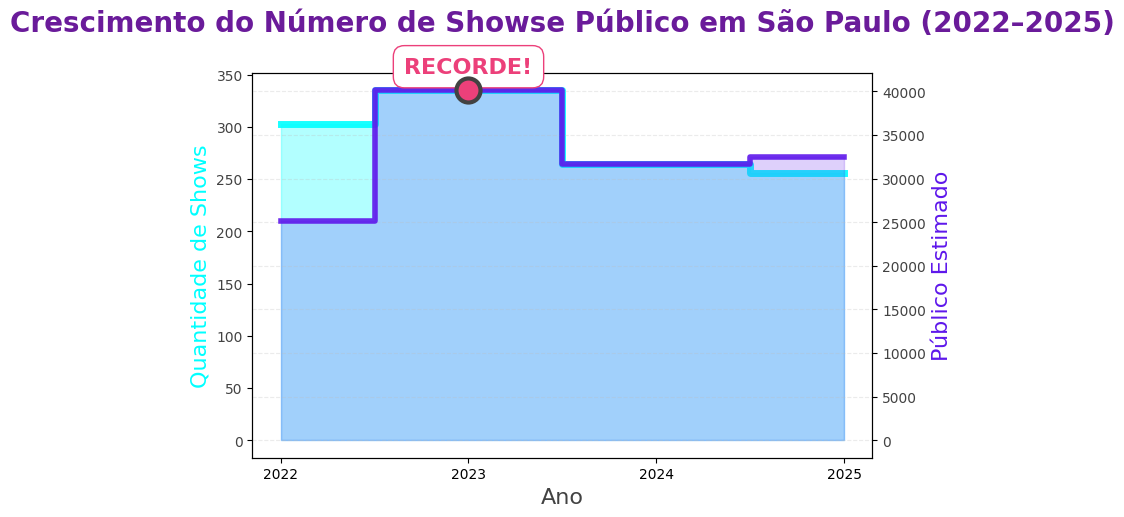

In [9]:
# Shows por ano (area)
x = df_plot['ano']
y = df_plot['total_shows']
y2 = df_plot['lotacao']

plt.figure(figsize=(8, 5))

plt.gcf().patch.set_facecolor('white')
ax = plt.gca()
ax.set_facecolor('white')

plt.fill_between(x, y, 0, step='mid', color='cyan', alpha=0.3) 
plt.plot(x, y, color='cyan', drawstyle='steps-mid', linewidth=5, alpha=0.9)
ax.set_xlabel('Ano', fontsize=16, color='#424242')
ax.set_ylabel('Quantidade de Shows', fontsize=16, color='cyan')
ax.tick_params(axis='y', labelcolor='#424242')

ax2 = ax.twinx()
ax2.fill_between(x, y2, 0, step='mid', color = '#5E17EB', alpha=0.2)
ax2.plot(x, y2, drawstyle='steps-mid', linewidth=4, color = '#5E17EB', alpha=0.9)
ax2.set_ylabel('Público Estimado', fontsize=16, color = '#5E17EB')
ax2.tick_params(axis='y', labelcolor='#424242')

# ano recorde
max_idx = np.argmax(y2)
plt.scatter(x[max_idx], y2[max_idx], color='#EC407A', s=300, zorder=5, edgecolor='#424242', linewidth=3)
plt.text(x[max_idx], y2[max_idx] + (y2.max()*0.05), 'RECORDE!', 
         fontsize=16, fontweight='bold', color='#EC407A', ha='center',
         bbox=dict(boxstyle="round,pad=0.5", facecolor='white', edgecolor='#EC407A'))

plt.title('Crescimento do Número de Showse Público em São Paulo (2022–2025)', fontsize=20, color='#6A1B9A', pad=30, fontweight='bold')
plt.grid(True, alpha=0.3, linestyle='--', color='#BDBDBD')

plt.xticks(x, fontsize=14, color='#424242')

plt.show()

In [10]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_plot['ano'],
    y=[1] * len(df_plot),
    mode='lines',
    line=dict(width=6, color='#00ACC1')
    )
)

fig.add_trace(go.Scatter(
    x=df_plot['ano'],
    y=[1] * len(df_plot),
    mode='markers+text',
    text=df_plot['total_shows'].astype(str) + ' shows<br>' + df_top5_grouped['top5_text'],
    textposition='top center',
    textfont=dict(size=12, color='#212121', family='Arial Black'),
    marker=dict(
        size=20,
        color='#4CAF50',
        line=dict(width=5, color='#FFC107'),  
        symbol='circle'
        )
    )
)

fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    font_color="#424242",
    title={
        'text': 'Linha do Tempo',
        'font': dict(size=20, color='#6A1B9A', family='Arial Black'),
        'x': 0.5,
        'xanchor': 'center'
    },
    showlegend=False, 
    yaxis=dict(range=[0, 3])
)
fig.update_yaxes(showticklabels=False)

fig.show()

Observa-se um pico no número de shows realizados e público estimado em 2022 e 2023, possivelmente relacionado ao reagendamento de eventos postergados durante a pandemia de COVID-19.

C:\Users\marin\AppData\Local\Temp\ipykernel_31008\621520547.py:7: FutureWarning:

The provided callable <function mean at 0x0000015D7F13CB80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.

C:\Users\marin\AppData\Local\Temp\ipykernel_31008\1959237411.py:57: UserWarning:

FixedFormatter should only be used together with FixedLocator



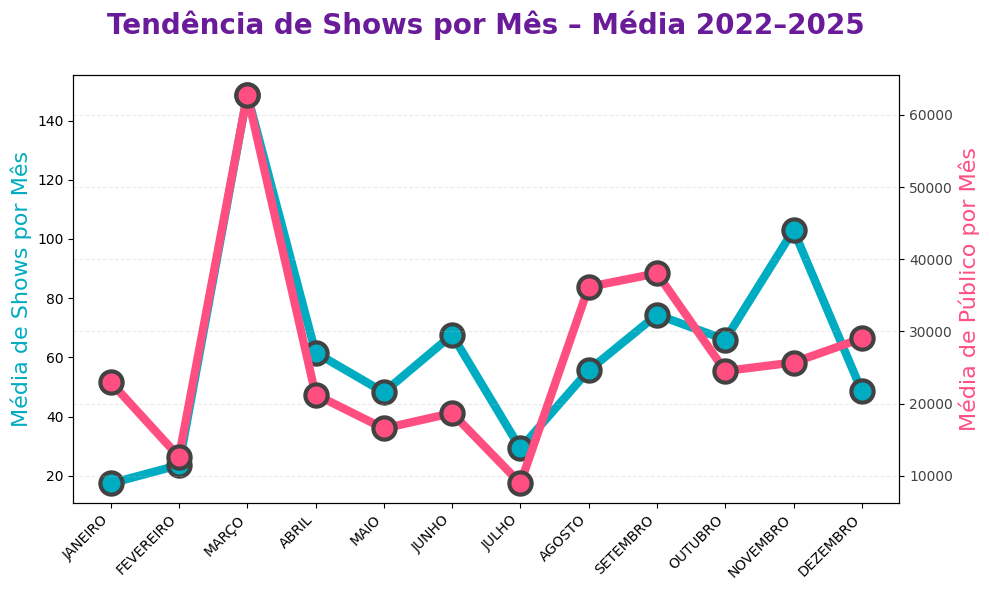

In [11]:
# Média de número de shows por mês 
plt.figure(figsize=(10,6))
ax = plt.gca()
ax.set_facecolor('white')
plt.gcf().patch.set_facecolor('white')

df_mes = agrupar(df, ['mes'], met='size').reset_index(name='total_shows')
lot_mes = agrupar(df, ['mes'], col_sel = 'lotacao').reset_index(name='lot_mean')
df_mes = df_mes.merge(lot_mes, on = 'mes', how = 'left')

ordem_meses = [
    'JANEIRO',
    'FEVEREIRO',
    'MARÇO',
    'ABRIL',
    'MAIO',
    'JUNHO',
    'JULHO',
    'AGOSTO',
    'SETEMBRO',
    'OUTUBRO',
    'NOVEMBRO',
    'DEZEMBRO'
]

df_mes['mes'] = pd.Categorical(df_mes['mes'], categories=ordem_meses, ordered=True)
df_mes = df_mes.sort_values('mes')

ax.plot(df_mes['mes'], df_mes['total_shows']/5,
         marker='o',
         markersize=16,
         markerfacecolor='#00ACC1',       
         markeredgecolor='#424242',       
         markeredgewidth=3,
         linewidth=6,
         color='#00ACC1',                
         label='Média mensal (2021–2025)')
ax.set_ylabel('Média de Shows por Mês', fontsize=16, color='#00ACC1')

ax2 = ax.twinx()
ax2.plot(df_mes['mes'], df_mes['lot_mean'],
         marker='o',
         markersize=16,
         markerfacecolor= '#FF4F81',       
         markeredgecolor='#424242',       
         markeredgewidth=3,
         linewidth=6,
         color='#FF4F81',                
         label='Média mensal (2021–2025)')
ax2.set_ylabel('Média de Público por Mês', fontsize=16, color='#FF4F81')


plt.title('Tendência de Shows por Mês – Média 2022–2025', fontsize=20, color='#6A1B9A', pad=30, fontweight='bold')

plt.xticks(fontsize=8, color='#424242')
plt.yticks(fontsize=10, color='#424242')
ax.set_xticklabels(df_mes['mes'], rotation=45, ha='right')

plt.xlabel('Mês', fontsize=10, color='#424242')

plt.grid(True, alpha=0.3, linestyle='--', color='#BDBDBD')

plt.tight_layout()
plt.show()

Observa-se uma maior média anual de shows nos meses de fevereiro e março, comportamento possivelmente associado à realização do festival Lollapalooza, tradicionalmente ocorrido nesse período. Além disso, nota-se um aumento da média de shows ao longo do segundo semestre, o que pode estar relacionado à realização bianual do festival The Town.

Em contraste, os meses de dezembro, janeiro e fevereiro apresentam dinâmicas específicas do calendário, como festas de fim de ano, férias escolares e maior deslocamento da população para viagens. Soma-se a esse contexto o período do Carnaval, caracterizado por uma grande quantidade de eventos musicais gratuitos distribuídos pela cidade, o que pode impactar tanto a oferta quanto o perfil dos shows registrados na base.

Em relação ao público estimado, o comportamento observado é bastante semelhante ao da quantidade de shows, com diferenças mais perceptíveis nos meses de janeiro e novembro, indicando possíveis variações na taxa média de ocupação desses períodos.

In [12]:
# Média de número de shows por dia da semana (pizza)

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{'type': 'domain'}, {'type': 'domain'}]],
    subplot_titles=[
        'Shows por Dia da Semana',
        'Lotação Média por Dia da Semana'
    ]
)

df_dia = ( agrupar(df, ['data', 'dia_semana'], met='size') .reset_index(name='shows_no_dia') ) 
df_sem_media = ( agrupar(df_dia, ['dia_semana'], col_sel='shows_no_dia', met='mean') .reset_index(name='media_shows') )
fig1 = px.pie(
    df_sem_media,
    values='media_shows',
    names='dia_semana',
    hole=0.4,
    color_discrete_sequence=['#5E17EB', '#9C27B0', '#00BCD4', '#4CAF50']
)
fig.add_trace(fig1.data[0], row=1, col=1)

df_dia2 = (agrupar(df, ['dia_semana'], col_sel = 'lotacao_pct').reset_index(name='lot_no_dia'))
fig2 = px.pie(
    df_dia2,
    values='lot_no_dia',
    names='dia_semana',
    hole=0.4,
    color_discrete_sequence=['#5E17EB', '#9C27B0', '#00BCD4', '#4CAF50']
)
fig.add_trace(fig2.data[0], row=1, col=2)

fig.update_traces(
    textposition='inside',
    textinfo='percent+label',
    textfont=dict(size=16, color='white'),
    marker=dict(line=dict(color='white', width=3)),
    hovertemplate='<b>%{label}</b><br>Valor: <b>%{value}</b><br>%{percent}<extra></extra>'
)

fig.update_layout(
    height=500,
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(color='black'),
    title=dict(
        text='Distribuição de Shows e Lotação por Dia da Semana',
        x=0.5,
        font=dict(size=22, color='#6A1B9A', family='Arial Black')
    ),
    margin=dict(t=100, b=50)
)

fig.show()

C:\Users\marin\AppData\Local\Temp\ipykernel_31008\621520547.py:7: FutureWarning:

The provided callable <function mean at 0x0000015D7F13CB80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.



A análise da distribuição de shows por dia da semana indica uma concentração significativa de eventos nos fins de semana (sexta-feira a domingo), que, em conjunto, representam mais de 60% do total de shows realizados. Diante desse padrão, optou-se por agrupar os dias da semana em dois grupos: dias úteis e fins de semana, com o objetivo de simplificar a análise e facilitar comparações posteriores.

Entretanto, ao analisar a lotação média por dia da semana, observa-se que não há diferenças expressivas no nível de engajamento do público entre os dias individualmente considerados. Esse resultado sugere que, apesar da maior concentração de eventos nos fins de semana, a lotação média não varia de forma significativa quando a análise é realizada de maneira mais granular por dia da semana.

In [13]:
fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{'type': 'domain'}, {'type': 'domain'}]],
    subplot_titles=[
        'Shows por dia',
        'Lotação Média por dia'
    ]
)

df_dia = (agrupar(df, ['data', 'tipo_dia'], met='size').reset_index(name='shows_no_dia'))
df_sem = (agrupar(df_dia, ['tipo_dia'], col_sel='shows_no_dia', met='mean').reset_index(name='media_shows'))
fig1 = px.pie(
    df_sem,
    values='media_shows',
    names='tipo_dia',
    hole=0.4,
    color_discrete_sequence=['#5E17EB', '#9C27B0', '#00BCD4', '#4CAF50']
)
fig.add_trace(fig1.data[0], row=1, col=1)

df_dia2 = (agrupar(df, ['tipo_dia'], col_sel = 'lotacao_pct').reset_index(name='lot_no_dia'))
fig2 = px.pie(
    df_dia2,
    values='lot_no_dia',
    names='tipo_dia',
    hole=0.4,
    color_discrete_sequence=['#5E17EB', '#9C27B0', '#00BCD4', '#4CAF50']
)
fig.add_trace(fig2.data[0], row=1, col=2)

fig.update_traces(
    textposition='inside',
    textinfo='percent+label',
    textfont=dict(size=16, color='white'),
    marker=dict(line=dict(color='white', width=3)),
    hovertemplate='<b>%{label}</b><br>Valor: <b>%{value}</b><br>%{percent}<extra></extra>'
)

fig.update_layout(
    height=500,
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(color='black'),
    title=dict(
        text='Distribuição de Shows e Lotação por "Tipo" da Semana',
        x=0.5,
        font=dict(size=22, color='#6A1B9A', family='Arial Black')
    ),
    margin=dict(t=100, b=50)
)

fig.show()

C:\Users\marin\AppData\Local\Temp\ipykernel_31008\621520547.py:7: FutureWarning:

The provided callable <function mean at 0x0000015D7F13CB80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.



A distribuição de shows por tipo de dia indica que fins de semana e feriados municipais apresentam proporções semelhantes de ocorrência de eventos (33% e 28%, respectivamente), ambas próximas a 30% do total. Em contraste, feriados nacionais e dias úteis concentram proporções menores e semelhantes entre si, em torno de 20%.

Esse padrão sugere que fins de semana e feriados municipais compartilham características comportamentais similares no que se refere à realização de shows, o que justifica sua agregação em um mesmo grupo analítico. No entanto, ao observar a lotação média por tipo de dia, verifica-se que o engajamento do público não segue a mesma proporção observada na distribuição de eventos, indicando que a maior oferta de shows em determinados tipos de dia não implica, necessariamente, maior lotação média.

In [14]:
df['descricao_clima'].unique()

array(['CHUVA LEVE', 'CHUVISCO LEVE', 'CHUVISCO MODERADO', 'NUBLADO',
       'CHUVISCO INTENSO', 'CHUVA FORTE', 'CHUVA MODERADA',
       '<FUNCTION SERIES.MODE AT 0X00000229E7721B20>',
       'PREDOMINANTEMENTE LIMPO', 'PARCIALMENTE NUBLADO', 'CEU LIMPO'],
      dtype=object)

In [15]:
df_clima1 = agrupar(df, ['descricao_clima'], col_sel='nome', met='nunique').reset_index(name='shows')
df_clima2 = agrupar(df, ['descricao_clima'], col_sel='lotacao_pct', met = np.mean)
df_clima = df_clima1.merge(df_clima2, how = 'inner', on = 'descricao_clima')

C:\Users\marin\AppData\Local\Temp\ipykernel_31008\621520547.py:7: FutureWarning:

The provided callable <function mean at 0x0000015D7F13CB80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.



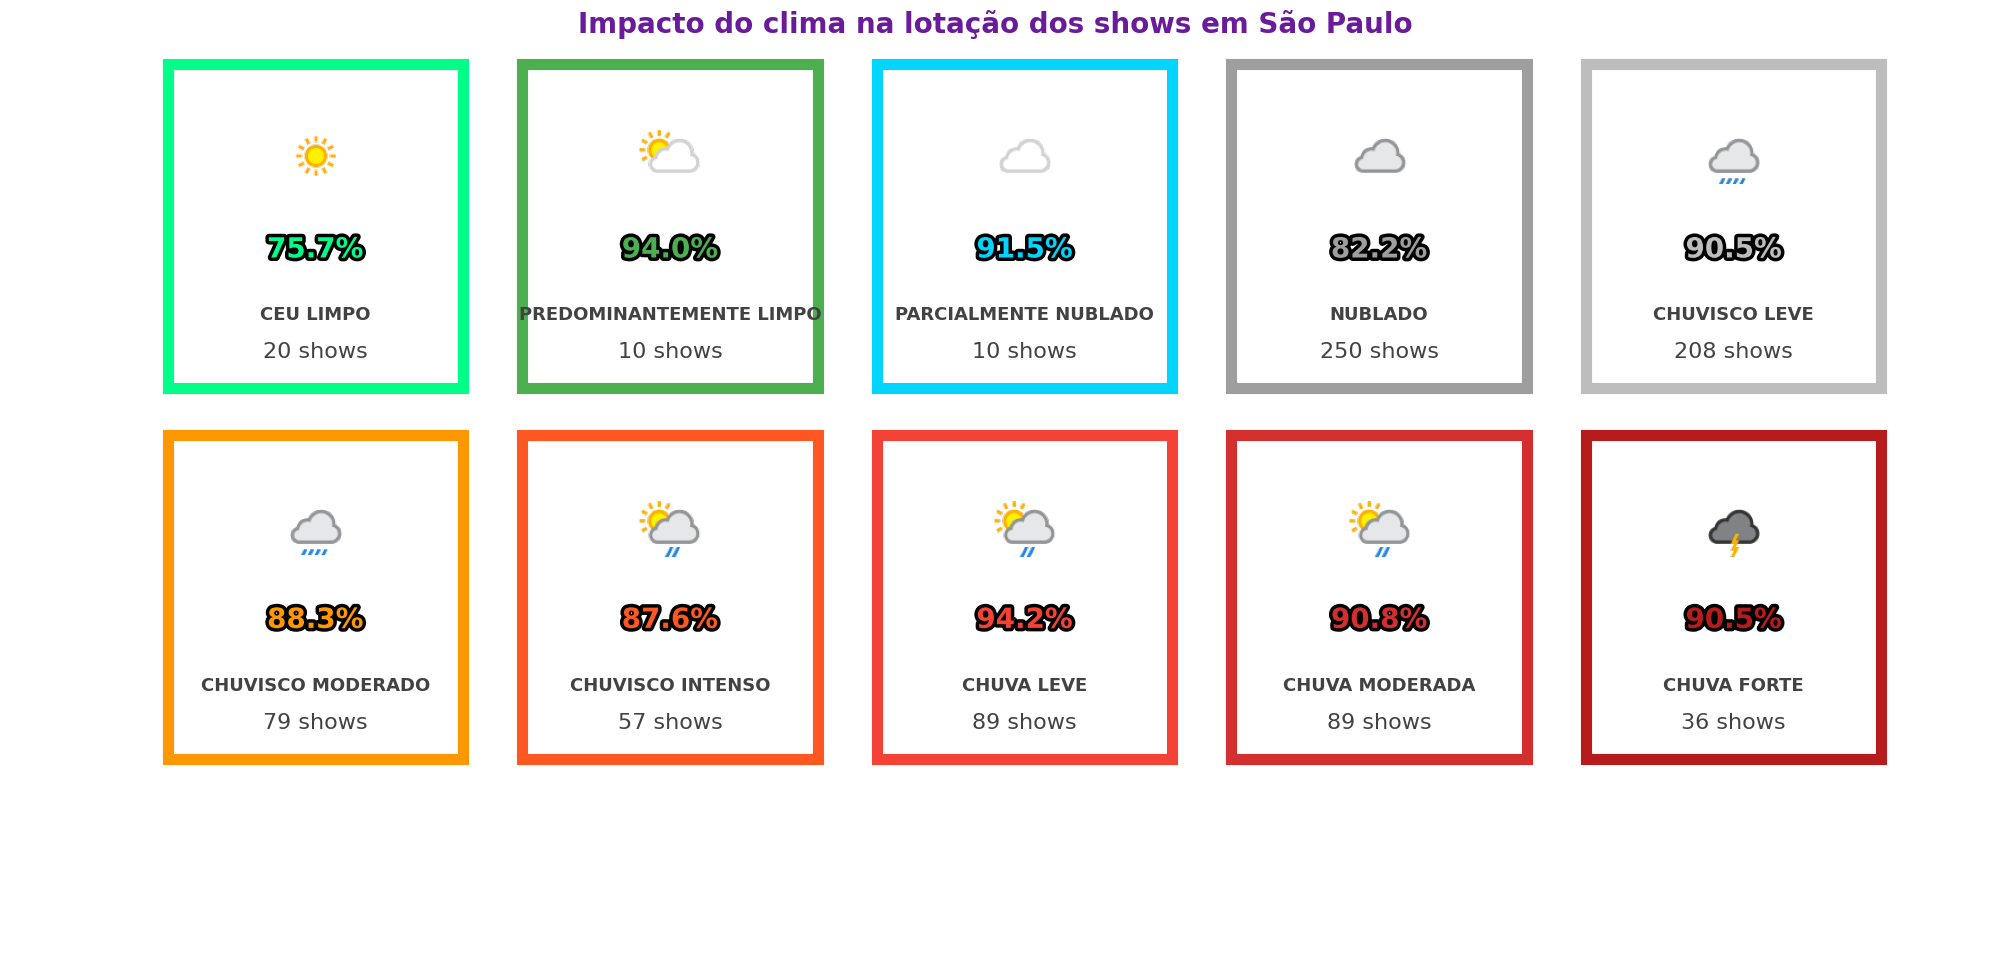

In [16]:
imagens_urls = {
    'CEU LIMPO': 'https://cdn.weatherapi.com/weather/64x64/day/113.png',
    'PREDOMINANTEMENTE LIMPO': 'https://cdn.weatherapi.com/weather/64x64/day/116.png',
    'PARCIALMENTE NUBLADO': 'https://cdn.weatherapi.com/weather/64x64/day/119.png',
    'NUBLADO': 'https://cdn.weatherapi.com/weather/64x64/day/122.png',
    'CHUVISCO LEVE': 'https://cdn.weatherapi.com/weather/64x64/day/263.png',
    'CHUVISCO MODERADO': 'https://cdn.weatherapi.com/weather/64x64/day/266.png',
    'CHUVISCO INTENSO': 'https://cdn.weatherapi.com/weather/64x64/day/299.png',
    'CHUVA LEVE': 'https://cdn.weatherapi.com/weather/64x64/day/176.png',
    'CHUVA MODERADA': 'https://cdn.weatherapi.com/weather/64x64/day/293.png',
    'CHUVA FORTE': 'https://cdn.weatherapi.com/weather/64x64/day/389.png'
}

imagens = {}
for clima, url in imagens_urls.items():
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content))
        imagens[clima] = img
    except Exception as e:
        print(f"Erro ao carregar {clima}: {e}")

lotacao_por_clima = dict(zip(df_clima['descricao_clima'], df_clima['lotacao_pct'] * 100))
qtd_shows = dict(zip(df_clima['descricao_clima'], df_clima['shows']))

# Ordem
climas = ['CEU LIMPO', 'PREDOMINANTEMENTE LIMPO', 'PARCIALMENTE NUBLADO', 'NUBLADO',
          'CHUVISCO LEVE', 'CHUVISCO MODERADO', 'CHUVISCO INTENSO',
          'CHUVA LEVE', 'CHUVA MODERADA', 'CHUVA FORTE']

fig, ax = plt.subplots(1, 1, figsize=(20, 10))  
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.axis('off')

cols = 5
rows = 2
cell_width = 0.18
cell_height = 0.4

for idx, clima in enumerate(climas):
    col = idx % cols
    row = idx // cols
    
    x = col * cell_width + 0.08
    y = 0.6 - row * cell_height  

    valor = lotacao_por_clima.get(clima, 0)
    shows = qtd_shows.get(clima, 0)

    cor_por_clima = {
        'CEU LIMPO': '#00FF88',
        'PREDOMINANTEMENTE LIMPO': '#4CAF50',
        'PARCIALMENTE NUBLADO': '#00D4FF',
        'NUBLADO': '#9E9E9E',
        'CHUVA LEVE': '#FFC107',
        'CHUVISCO MODERADO': '#FF9800',
        'CHUVISCO INTENSO': '#FF5722',
        'CHUVA LEVE': '#F44336',
        'CHUVA MODERADA': '#D32F2F',
        'CHUVA FORTE': '#B71C1C'
    }
    cor = cor_por_clima.get(clima, '#BDBDBD')

    rect = patches.Rectangle((x, y), cell_width-0.03, cell_height-0.05,
                            linewidth=8, edgecolor=cor, facecolor='white', alpha=1.0)
    ax.add_patch(rect)

    if clima in imagens:
        img = imagens[clima]
        imagebox = OffsetImage(img, zoom=0.8)  # imagem maior
        ab = AnnotationBbox(imagebox, (x + cell_width/2 - 0.015, y + 0.25), frameon=False)
        ax.add_artist(ab)

    # % de lotação 
    ax.text(x + cell_width/2 - 0.015, y + 0.15, f'{valor:.1f}%',
            ha='center', va='center', fontsize=20, fontweight='bold', color=cor,
            path_effects=[patheffects.withStroke(linewidth=5, foreground='black')])

    # Nome do clima 
    ax.text(x + cell_width/2 - 0.015, y + 0.08, clima, ha='center', va='center', fontsize=13, color='#424242', fontweight='bold')

    # Quantidade de shows
    ax.text(x + cell_width/2 - 0.015, y + 0.04, f'{shows} shows', ha='center', va='center', fontsize=16, color='#424242')


plt.suptitle('Impacto do clima na lotação dos shows em São Paulo', fontsize=20, color='#6A1B9A', y=0.95, fontweight='bold')

plt.tight_layout()
plt.show()

Nota-se que, a partir da análise exploratória realizada, não se observa uma associação evidente entre as variáveis climáticas e a presença do público ou a ocorrência de shows.

In [17]:
# Filtra os "primeiros shows" de cada gênero (distância 999)
df_dist = df[df['distancia_dias_anterior'] < 999].copy()

# Cria faixas de distância para melhor visualização (bins)
bins = [0, 7, 14, 30, 60, 90, 180, 365, float('inf')]
labels = ['0-7 dias', '8-14 dias', '15-30 dias', '31-60 dias', 
          '61-90 dias', '91-180 dias', '181-365 dias', '>1 ano']

df_dist['faixa_distancia'] = pd.cut(
    df_dist['distancia_dias_anterior'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True
)
    
df_dist['faixa_distancia'] = pd.Categorical(
    df_dist['faixa_distancia'], 
    categories=labels,
    ordered = False
)

df_dist = df_dist.sort_values('distancia_dias_anterior')

fig_box = px.box(
    df_dist,
    x='faixa_distancia',
    y='lotacao', 
    color='faixa_distancia', 
    color_discrete_sequence=px.colors.sequential.Plasma_r, 
    points='outliers',
    title='Impacto da Distância Temporal entre Shows do Mesmo Gênero no Público',
    labels={
        'faixa_distancia': 'Distância desde o Show Anterior do Mesmo Gênero',
        'publico_absoluto': 'Público Absoluto (pessoas)'
    },
    height=600
)

fig_box.update_traces(
    boxmean=True,  
    marker=dict(size=6),
    line=dict(width=2)
)

fig_box.update_layout(
    showlegend=False,
    xaxis_title='Distância Temporal até o Show Anterior',
    yaxis_title='Público Absoluto (número de pessoas)',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font_family="Arial",
    title={
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=20, color='#6A1B9A', family='Arial Black')
    },
    yaxis=dict(
        showgrid=True,
        gridcolor='#E0E0E0',
        gridwidth=1,
        zeroline=True,
        zerolinecolor='#9E9E9E'
    ),
    xaxis=dict(
        showgrid=False
    )
)

fig_box.show()

O intervalo de tempo entre shows de um mesmo gênero musical sugere possível influência sobre o público médio dos eventos subsequentes. Observa-se a presença de valores extremos (outliers), especialmente em shows realizados após períodos mais longos sem ocorrências do mesmo gênero. Nesses casos, identifica-se, em alguns pontos, maior lotação média quando o intervalo supera 90 dias; entretanto, esse comportamento não se apresenta de forma constante ou linear ao longo dos dados analisados.

#### Principais locais, artistas e gêneros

In [18]:
# Mapa (tamanho da bolha = número de shows)

df_local = agrupar(df, 'nome_local', met = 'size').reset_index(name='total_shows')
df_local = df_local.merge(df, on = ['nome_local'], how ='left')

map = px.scatter_map(df_local, 
                     lat = 'Latitude', 
                     lon = 'Longitude', 
                     size = 'total_shows', 
                     hover_name='nome_local', 
                     color='total_shows',
                     color_continuous_scale=['#5E17EB', '#FF2E78', '#00D4FF', '#00FF88', '#FFEA00'],  
                     title = 'Quantidade de Shows por Local',
                     height=600
                    )

map.update_layout(mapbox_style='basic')

map.update_layout(
    margin=dict(l=0, r=0, t=80, b=0),
    font_color='#424242',
    title_font_color='#6A1B9A', 
    title={
           'x': 0.5,
           'xanchor': 'center',
           'font': dict(size=20, color='#6A1B9A', family='Arial Black')
          }
)
map.show()

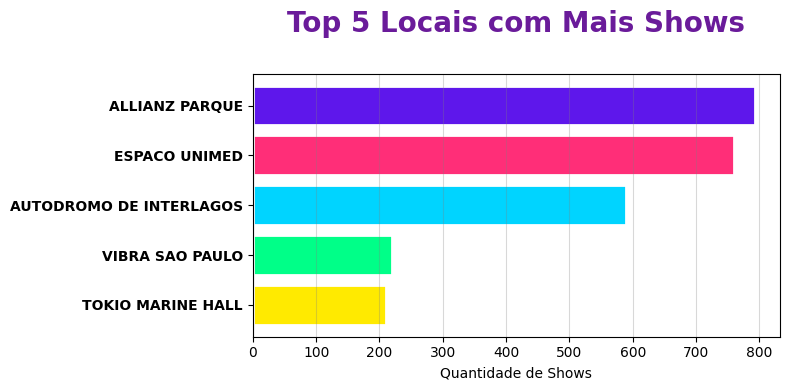

In [19]:
# barras top 5 locais
loc_n  = top_n(5, df, ['nome_local'], met = 'size')

plt.figure(figsize=(8,4))

plt.barh(loc_n['nome_local'], loc_n[0],
         color=['#5E17EB', '#FF2E78', '#00D4FF', '#00FF88', '#FFEA00'],  
         edgecolor='#FFFFFF',
         linewidth=2)

plt.xlabel('Quantidade de Shows')
plt.title('Top 5 Locais com Mais Shows', fontsize=20, color='#6A1B9A', pad=30, fontweight='bold')
plt.gca().invert_yaxis()  

plt.gca().set_facecolor('white')
plt.gcf().patch.set_facecolor('white')
plt.grid(axis='x', color='grey', alpha=0.3)

plt.xticks(color='#000000')
plt.yticks(color='#000000', fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\marin\AppData\Local\Temp\ipykernel_31008\621520547.py:7: FutureWarning:

The provided callable <function mean at 0x0000015D7F13CB80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.



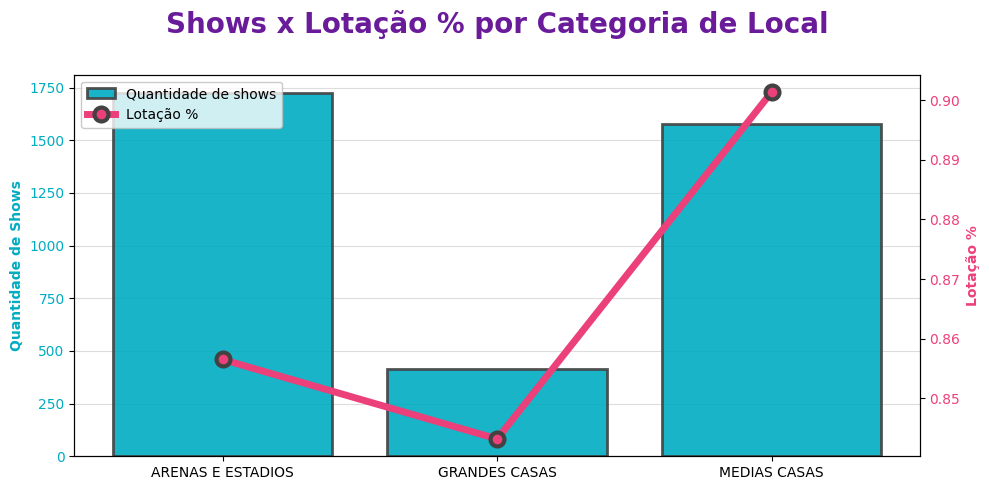

In [20]:
# Colunas tipo de local x quantidade de show e linha público
qtd = pd.DataFrame(agrupar(df, ['Categoria_Local'], met='size'))
lot = pd.DataFrame(agrupar(df, ['Categoria_Local'], col_sel='lotacao_pct', met = np.mean))

qtd = qtd.rename(columns={0: 'qtd_shows'})

df_bar = qtd.merge(lot, on=lot.index)

categorias = df_bar.index

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.set_facecolor('w')
fig.patch.set_facecolor('w')

ax1.bar(df_bar['key_0'], 
        df_bar['qtd_shows'],
        color='#00ACC1',           
        edgecolor='#424242', 
        linewidth=2,
        alpha=0.9,
        label='Quantidade de shows')
ax1.set_ylabel('Quantidade de Shows', color='#00ACC1', fontsize=10, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='#00ACC1')

ax2 = ax1.twinx()
ax2.plot(df_bar['key_0'], 
         df_bar['lotacao_pct'], 
         marker='o', 
         markersize=10,
         markerfacecolor='#EC407A',     
         markeredgecolor='#424242',
         markeredgewidth=3,
         linewidth=5,
         color='#EC407A',               
         label='Lotação %')

ax2.set_ylabel('Lotação %', color='#EC407A', fontsize=10, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#EC407A')

plt.title('Shows x Lotação % por Categoria de Local', color='#6A1B9A', fontsize=20, fontweight='bold', pad=30)

plt.xticks(ticks=df_bar['key_0'], 
           labels=df_bar['key_0'], 
           rotation=20, 
           color='#424242', 
           fontsize=12)

ax1.grid(True, axis='y', color='#BDBDBD', alpha=0.5)
ax1.set_axisbelow(True)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='#BDBDBD')

plt.tight_layout()
plt.show()

A análise dos dois últimos gráficos indica que a capacidade dos locais não apresenta uma relação evidente com a quantidade de shows realizados em cada um. Observa-se, por exemplo, que espaços com capacidades bastante distintas — como o Autódromo de Interlagos (aproximadamente 100.000 pessoas), o Espaço Unimed (cerca de 8.000 pessoas) e o Tokio Marine Hall (entre 3.000 e 4.000 pessoas) — apresentam padrões de realização de eventos que não seguem uma lógica diretamente associada ao tamanho do local.

Comportamento semelhante é observado na análise da lotação dos locais, na qual não se identifica uma relação clara entre a capacidade máxima e o nível de ocupação média. Esses resultados sugerem que outros fatores, como preferências do público, perfil dos artistas e percepção de qualidade do evento ou do espaço, podem exercer maior influência sobre a realização e a lotação dos shows do que a capacidade nominal dos locais.

In [21]:
tr1 = agrupar(df, ['generos'], met='size')
tr1 = tr1.reset_index()   
tr1.columns = ['generos', 'qtd']  

tree_1 = px.treemap(
    tr1,
    path=['generos'],
    values='qtd',
    color_continuous_scale=['#5E17EB', '#9C27B0', '#00BCD4', '#4CAF50', '#FFEA00'], 
    title = 'Quantidade de Shows por Genêro Musical'
)
tree_1.update_traces(
    textinfo='label+value+percent root',
    textfont=dict(size=10, family='Arial Black'),
    marker_line=dict(width=4, color='#000000'),
    hovertemplate='<b>%{label}</b><br>Shows: <b>%{value}</b> (%{percentRoot:.1%} do total)<extra></extra>'
)

tree_1.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    title_font=dict(size=20, color='#6A1B9A', family='Arial Black'),
    font_color='#424242',
    margin=dict(t=80, l=0, r=0, b=0)
)

tree_1.show()

In [22]:
tr2 = agrupar(df, ['generos'], col_sel = 'lotacao', met = 'sum')
tr2 = tr2.reset_index()   
tr2.columns = ['generos', 'lot']  

tree_2 = px.treemap(
    tr2,
    path=['generos'],
    values='lot',
    color_continuous_scale=['#5E17EB', '#9C27B0', '#00BCD4', '#4CAF50', '#FFEA00'],
    title = 'Público Total em Shows por Genêro Musical'
)
tree_2.update_traces(
    textinfo='label+value+percent root',
    textfont=dict(size=10, family='Arial Black'),
    marker_line=dict(width=4, color='#000000'),
    hovertemplate='<b>%{label}</b><br>Shows: <b>%{value}</b> (%{percentRoot:.1%} do total)<extra></extra>'
)

tree_2.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    title_font=dict(size=20, color='#6A1B9A', family='Arial Black'),
    font_color='#424242',
    margin=dict(t=80, l=0, r=0, b=0)
)

tree_2.show()

In [23]:
tr3_g = agrupar(df, ['generos'], col_sel = 'arrecadacao_estimada', met = 'sum')
tr3_g = tr3_g.reset_index()   
tr3_g.columns = ['generos', 'arrecadacao_estimada']

tree_3 = px.treemap(
    tr3_g,
    path=['generos'],
    values='arrecadacao_estimada',
    color_continuous_scale=['#5E17EB', '#9C27B0', '#00BCD4', '#4CAF50', '#FFEA00'],
    title = 'Arrecadação em Shows por Genêro Musical'
)
tree_3.update_traces(
    textinfo='label+value+percent root',
    textfont=dict(size=10, family='Arial Black'),
    marker_line=dict(width=4, color='#000000'),
    hovertemplate='<b>%{label}</b><br>Shows: <b>%{value}</b> (%{percentRoot:.1%} do total)<extra></extra>'
)

tree_3.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white",
    title_font=dict(size=20, color='#6A1B9A', family='Arial Black'),
    font_color='#424242',
    margin=dict(t=80, l=0, r=0, b=0)
)

tree_3.show()

O distanciamento temporal entre shows de um mesmo gênero musical sugere interferir no público absoluto médio dos eventos subsequentes. Observa-se a presença de alguns outliers nesses valores, com maiores lotações associadas a intervalos mais longos entre shows — especialmente quando superiores a 90 dias. No entanto, esse aumento não ocorre de forma linear ou constante, indicando que o tempo entre eventos, isoladamente, não explica totalmente a variação de público.

Nos dois últimos gráficos analisados, percebe-se que o tamanho do local não apresenta relação direta com a quantidade de shows realizados. Espaços com capacidades muito distintas, como o Autódromo de Interlagos (aproximadamente 100 mil pessoas), o Espaço Unimed (cerca de 8 mil) e o Tokio Marine Hall (entre 3 mil e 4 mil pessoas), apresentam números de eventos que não refletem essa diferença de escala. Isso indica que outros fatores exercem maior influência nessa dinâmica, como a preferência do público e a percepção de qualidade associada aos eventos e aos locais. Esse comportamento também se repete na análise da taxa de lotação das casas, na qual não se identifica uma lógica clara relacionada ao tamanho do espaço.

Ao analisar os três treemaps apresentados, observa-se um comportamento semelhante quando considerados o público e a arrecadação estimada por gênero musical, mas um padrão distinto quando analisada a quantidade de shows. Como exemplo, o gênero MPB representa cerca de 14% dos shows realizados, porém responde por aproximadamente 2,5% da arrecadação total e cerca de 4% do público. Em contraste, o gênero Pop ocupa a segunda posição tanto em arrecadação (7%) quanto em público (8%), mas aparece apenas na sexta posição em número de shows, com aproximadamente 5% do total. Esses resultados sugerem que a quantidade de eventos por gênero não está necessariamente alinhada ao seu impacto financeiro ou à sua capacidade de atrair público.

In [24]:
# Funil top 7 nomes por shows

art_n  = top_n(7, df, ['nome'], met = 'size')

top_art = px.funnel(
    art_n, 
    x='nome', 
    y=0,
    title='Top 7 nomes por quantidade de shows',
    color_discrete_sequence=['#9C27B0'],
    height=600,
    labels={'nome': ''} 
)

top_art.update_traces(
    textinfo='value+percent initial',
    textfont=dict(size=15, family='Arial Black'),
    marker=dict(line=dict(color='#FFFFFF', width=4)),
    hovertemplate='<b>%{x}</b><br>Shows: <b>%{y}</b><br>Participação: %{percentInitial:.1%}<extra></extra>'
)

top_art.update_layout(
    title={
        'text': 'Top 7 nomes que mais se apresentaram em SP (2022–2025)',
        'font': dict(size=20, color='#6A1B9A', family='Arial Black'),
        'x': 0.5,
        'xanchor': 'center'
    },
    paper_bgcolor='#FFFFFF',
    plot_bgcolor='#FFFFFF',
    font_color='#000000',
    margin=dict(t=100, l=50, r=0, b=0)
)

top_art.update_traces(
    marker=dict(line=dict(color=['#00BCD4'] + ['#FFFFFF']*6, width=[6] + [4]*6))
)

top_art.show()

In [25]:
# Funil top 7 nomes por lotação

art_s  = top_n(7, df, 'nome', col_sel = 'lotacao', met = 'sum')

top_s = px.funnel(
    art_s, 
    y='nome', 
    x='lotacao',
    title='Top 7 nomes por lotação total (2022–2025)',
    color_discrete_sequence=['#9C27B0'],
    height=650,
    labels={'nome': ''} 
)


top_s.update_traces(
    textinfo='value+percent initial',
    textfont=dict(size=15, family='Arial Black'),
    marker=dict(line=dict(color='#FFFFFF', width=5)),
    hovertemplate='<b>%{y}</b><br>Lotação total: <b>%{x:,.0f}</b> pessoas<br>Participação: %{percentInitial:.1%}<extra></extra>'
)

top_s.update_traces(
    marker=dict(line=dict(color=['#00BCD4'] + ['#FFFFFF']*6, width=[8] + [5]*6))
)

top_s.update_layout(
    title={
        'text': 'Quem mais levou gente pro show em SP (2022-2025)',
        'font': dict(size=20, color='#6A1B9A', family='Arial Black'),
        'x': 0.5,
        'xanchor': 'center'
    },
    paper_bgcolor='#FFFFFF',
    plot_bgcolor='#FFFFFF',
    font_color='#000000',
    margin=dict(t=110, l=60, r=60, b=50)
)

top_s.show()

In [26]:
# Funil top 7 nomes por arrecadação

art_top7 = df.sort_values('arrecadacao_estimada', ascending=False).head(7)
art_top7 = art_top7.drop_duplicates()

top_a = px.funnel(
    art_top7, 
    y='arrecadacao_estimada', 
    x='nome',
    title='Top 7 nomes por arrecadação bruta estimada (2022–2025)',
    color_discrete_sequence=['#9C27B0'],
    height=650,
    labels={'nome': ''} 
)

top_a.update_traces(
    textinfo='value+percent initial',
    textfont=dict(size=15, family='Arial Black'),
    marker=dict(line=dict(color='#FFFFFF', width=5))
)

top_a.update_traces(
    marker=dict(line=dict(color=['#00BCD4'] + ['#FFFFFF']*6, width=[8] + [5]*6))
)

top_a.update_layout(
    title={
        'text': 'Quem mais FATUROU em São Paulo (2022–2025)',
        'font': dict(size=20, color='#6A1B9A', family='Arial Black'),
        'x': 0.5,
        'xanchor': 'center'
    },
    paper_bgcolor='#FFFFFF',
    plot_bgcolor='#FFFFFF',
    font_color='#000000',
    margin=dict(t=110, l=60, r=60, b=50)
)

top_a.show()

Quando a análise é realizada por artista, em vez de por gênero musical, observa-se um comportamento significativamente distinto em relação à lotação, ao número de shows e à arrecadação estimada. Nota-se que o funil de público apresenta maior similaridade com o funil de quantidade de shows do que com o funil de arrecadação. Esse resultado sugere que, para artistas individuais, a frequência de apresentações está mais diretamente associada ao volume total de público alcançado do que ao retorno financeiro gerado, indicando possíveis diferenças de estratégia de precificação, perfil de público ou tipo de local utilizado.

C:\Users\marin\AppData\Local\Temp\ipykernel_31008\621520547.py:7: FutureWarning:

The provided callable <function mean at 0x0000015D7F13CB80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.

C:\Users\marin\AppData\Local\Temp\ipykernel_31008\621520547.py:7: FutureWarning:

The provided callable <function mean at 0x0000015D7F13CB80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.

C:\Users\marin\AppData\Local\Temp\ipykernel_31008\621520547.py:7: FutureWarning:

The provided callable <function mean at 0x0000015D7F13CB80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.



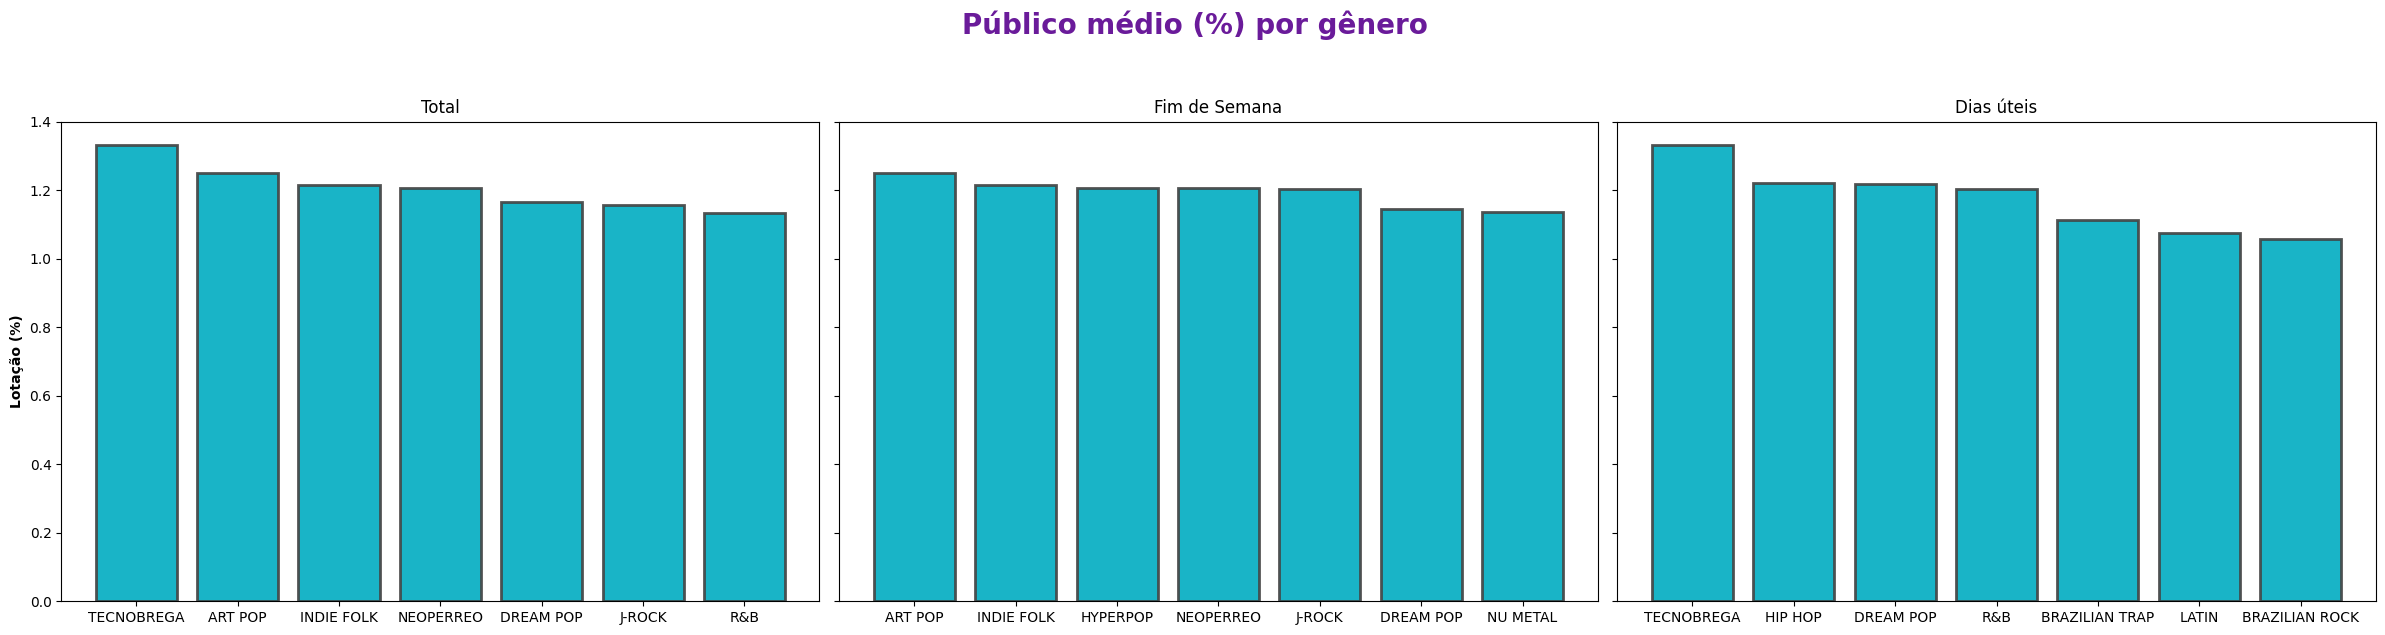

In [27]:
fds = ['SEXTA-FEIRA', 'SABADO', 'DOMINGO']

df_fds = df[df['dia_semana'].isin(fds)]
df_sm  = df[~df['dia_semana'].isin(fds)]

fig, ax = plt.subplots(1, 3, figsize=(24, 6), sharey=True)

df1 = top_n(7, df, ['generos'], col_sel = 'lotacao_pct')
ax[0].bar(
    df1['generos'],
    df1['lotacao_pct'],
    edgecolor='#424242',
    linewidth=2,
    alpha=0.9, 
    color = '#00ACC1'
)
ax[0].set_title('Total')

df_fds = top_n(7, df_fds, ['generos'], col_sel = 'lotacao_pct')
ax[1].bar(
    df_fds['generos'],
    df_fds['lotacao_pct'],
    edgecolor='#424242',
    linewidth=2,
    alpha=0.9,
    color = '#00ACC1'
)
ax[1].set_title('Fim de Semana')

df_sm = top_n(7, df_sm, ['generos'], col_sel = 'lotacao_pct')
ax[2].bar(
    df_sm['generos'],
    df_sm['lotacao_pct'],
    edgecolor='#424242',
    linewidth=2,
    alpha=0.9,
    color = '#00ACC1'
)
ax[2].set_title('Dias úteis')

ax[0].set_ylabel('Lotação (%)', fontsize=10, fontweight='bold')

fig.suptitle(
    'Público médio (%) por gênero',
    fontsize=20,
    fontweight='bold',
    y=1.05, 
    color='#6A1B9A'
)

plt.tight_layout()
plt.show()

Nota-se que o comportamento do público em relação aos gêneros musicais e à lotação dos shows é semelhante quando comparamos o total de eventos com aqueles realizados nos fins de semana. Esse padrão também se mantém ao analisar os shows que apresentam maiores níveis de ocupação, indicando que a diferença entre apresentações em dias úteis e em fins de semana não altera de forma significativa quais gêneros mais lotam os espaços nem o percentual médio de ocupação observado.

C:\Users\marin\AppData\Local\Temp\ipykernel_31008\621520547.py:7: FutureWarning:

The provided callable <function mean at 0x0000015D7F13CB80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.

C:\Users\marin\AppData\Local\Temp\ipykernel_31008\621520547.py:7: FutureWarning:

The provided callable <function mean at 0x0000015D7F13CB80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.



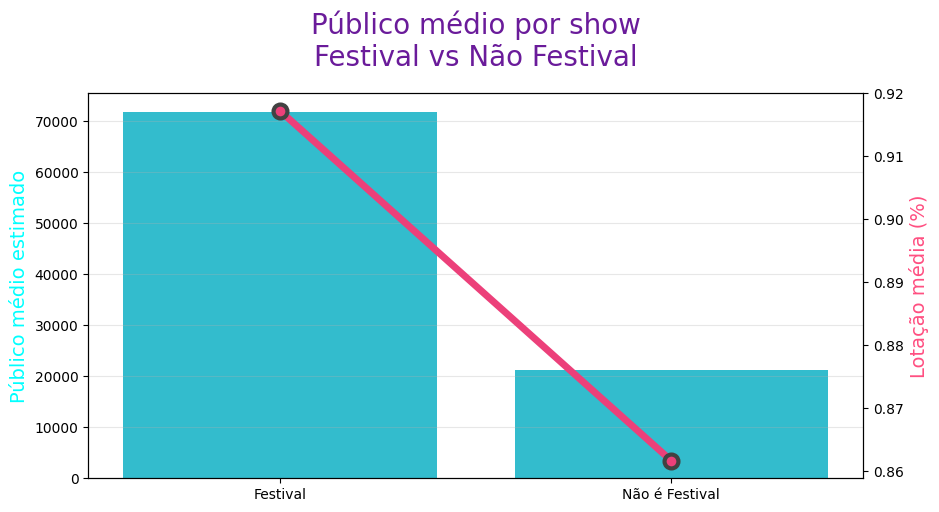

In [28]:
df['eh_festival'] = df['festival'].apply(lambda x: 'Festival' if x != 'False' else 'Não é Festival')
df_fest = agrupar(df, 'eh_festival', 'lotacao').reset_index('eh_festival')
df_fest2 = agrupar(df, 'eh_festival', 'lotacao_pct').reset_index('eh_festival')
df_fest = df_fest.merge(df_fest2, on = 'eh_festival', how = 'left')

fig, ax1 = plt.subplots(figsize=(10,5))
ax2 = ax1.twinx()

ax1.bar(
    df_fest['eh_festival'],
    df_fest['lotacao'],
    color='#00ACC1',
    alpha=0.8
)

ax2.plot(
    df_fest['eh_festival'],
    df_fest['lotacao_pct'],
    color='#EC407A',
    zorder=5,
    marker = 'o',
    markersize=10,
    markerfacecolor='#EC407A',     
    markeredgecolor='#424242',
    markeredgewidth=3,
    linewidth=5
)

ax1.set_ylabel('Público médio estimado', fontsize=14, color = 'cyan')
ax2.set_ylabel('Lotação média (%)', fontsize=14, color='#FF4F81')
ax2.tick_params(axis='y')

plt.title(
    'Público médio por show\nFestival vs Não Festival',
    fontsize=20,
    color='#6A1B9A',
    pad=20
)

ax1.grid(axis='y', alpha=0.3)
plt.show()

Shows realizados em festivais musicais atraem um público muito maior e apresentam níveis mais elevados de engajamento em comparação com shows individuais, o que sugere se caracterizarem como outliers, assim não devem ser considerados na modelagem.

In [29]:
df = df[df['eh_festival'] == 'Não é Festival']

#### Características do local

In [30]:
# % público considerando a casa
lot_pct = df['lotacao_pct'].value_counts(bins=[0,0.05,0.70,0.85,0.95,1.50], sort=False).reset_index()
lot_pct.columns = ['faixa', 'quantidade']
lot_pct['faixa'] = ['<50%', '50–70%', '70–85%', '85–95%', '>95%']

cores = ['#5E17EB', '#9C27B0', '#00BCD4', '#4CAF50', '#FFEA00'] 

fig_house = px.bar(
    lot_pct,
    x='faixa',
    y='quantidade',
    color='faixa',
    color_discrete_sequence=cores,
    text='quantidade',
    height=600
)

# Ajustes visuais
fig_house.update_traces(
    textposition='outside',
    textfont_size=16,
    marker_line_width=2,
    marker_line_color= '#6A1B9A'
)

fig_house.update_layout(
    showlegend=False,
    xaxis_title='Taxa de Lotação',
    yaxis_title='Número de Shows',
    plot_bgcolor='white', 
    paper_bgcolor='white',
    font_family="Arial",
    bargap=0.2, 
    title={
        'text': 'Distribuição da Taxa de Lotação dos Shows em São Paulo (2021–2025)',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=22, color='#6A1B9A', family='Arial Black')
    }, 
    yaxis=dict(
        showgrid=True,         
        gridwidth=0.5,            
        gridcolor='#BDBDBD',    
        zeroline=True,
        zerolinecolor='#9E9E9E',
        zerolinewidth=2
    )
)


# Anotação especial para >95% = SOLD OUT
max_y = lot_pct['quantidade'].max()
fig_house.add_annotation(
    x='>95%',
    y=lot_pct.loc[lot_pct['faixa'] == '>95%', 'quantidade'].values[0] + max_y * 0.05,
    text='>95% = SOLD OUT!',
    showarrow=True,
    arrowhead=2,
    arrowcolor='#39FF14',
    font=dict(size=18, color='#39FF14', family='Arial Black'),
    bgcolor='rgba(0,0,0,0.7)',
    bordercolor='#39FF14',
    borderwidth=2,
    borderpad=8
)

# Mostrar gráfico
fig_house.show()                                                                                               

Observa-se que a maior parte dos shows realizados em São Paulo apresenta um público estimado superior a 95% da capacidade nominal dos locais. No entanto, não se identifica um crescimento constante da taxa de lotação à medida que o número de shows aumenta, indicando que a frequência de eventos não está diretamente associada a um aumento progressivo da ocupação dos espaços.

In [31]:
agrupado = df.groupby('Categoria_Setor').agg(
    num_shows=('Categoria_Setor', 'size'),
    preco_medio=('preco', 'mean'),
    lotacao_media=('lotacao_pct', 'mean')
).reset_index()

agrupado = agrupado.sort_values('num_shows', ascending=False)

fig = make_subplots(specs=[[{"secondary_y": True}]])

# Número de shows
fig.add_trace(
    go.Bar(
        x=agrupado['Categoria_Setor'],
        y=agrupado['num_shows'],
        name='Número de Shows',
        marker_color='#00BCD4',
        text=agrupado['num_shows'],
        textposition='outside',
        width=0.35,  
        offsetgroup=0 
    ),
    secondary_y=False
)

# Preço médio
fig.add_trace(
    go.Bar(
        x=agrupado['Categoria_Setor'],
        y=agrupado['preco_medio'],
        name='Preço Médio (R$)',
        marker_color='#FFEA00',
        text=agrupado['preco_medio'].round(0).astype(int),
        textposition='outside',
        width=0.35,  
        offsetgroup=1  
    ),
    secondary_y=False
)

fig.add_trace(
    go.Scatter(
        x=agrupado['Categoria_Setor'],
        y=agrupado['lotacao_media'] * 100,
        mode='lines+markers+text',
        name='Lotação Média (%)',
        line=dict(color='#9C27B0', width=5),
        marker=dict(size=12, symbol='diamond'),
        text=[f"{v:.1f}%" for v in agrupado['lotacao_media'] * 100],
        textposition='top center'
    ),
    secondary_y=True
)

fig.update_layout(
    title={
        'text': 'Análise por Categoria de Setor: Quantidade, Preço e Lotação',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=20, color='#6A1B9A', family='Arial Black')
    },
    xaxis_title='Categoria de Setor',
    yaxis_title='Número de Shows',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    barmode='group',
    bargap=0.15,
    bargroupgap=0.05,
    height=700,
    hovermode='x unified', 
    plot_bgcolor='white',
    paper_bgcolor='white',
    yaxis=dict(
        showgrid=True,         
        gridwidth=0.5,            
        gridcolor='#BDBDBD',    
        zeroline=True,
        zerolinecolor='#9E9E9E',
        zerolinewidth=2
    )
)

fig.update_yaxes(range=[0, agrupado['preco_medio'].max() * 1.1], secondary_y=False)
fig.update_yaxes(range=[0, max(agrupado['lotacao_media'].max() * 1.1, 110)], secondary_y=True)
fig.update_yaxes(title_text='Preço Médio (R$) / Lotação Média (%)', secondary_y=True)

fig.show()

A presença de setores com diferentes níveis de luxo não parece interferir de forma significativa na presença de público nos shows. Observa-se uma predominância de setores comuns, além de um comportamento quase inverso entre o valor do ingresso e a frequência de shows que apresentam determinado tipo de setor: quanto maior o preço associado ao setor, menor tende a ser o número de eventos que o oferecem.

#### Relações com popularidade

C:\Users\marin\AppData\Local\Temp\ipykernel_31008\621520547.py:7: FutureWarning:

The provided callable <function mean at 0x0000015D7F13CB80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.



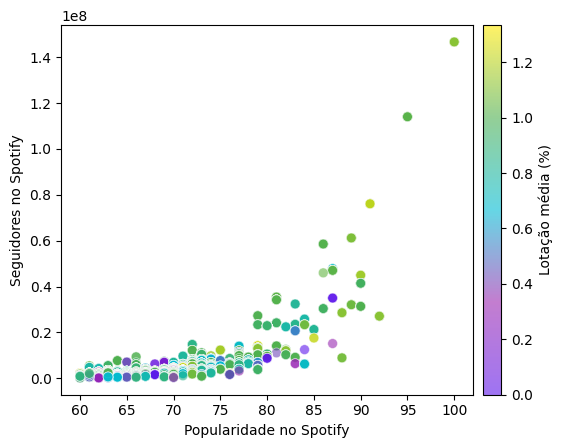

In [32]:
# Média de público por popularidade e seguidores no spotify (scatter)
lotacao_media = agrupar(df, ['nome'], col_sel = 'lotacao_pct')
cores_lotacao = ['#5E17EB', '#9C27B0', '#00BCD4', '#4CAF50', '#FFEA00']
cmap_neon = LinearSegmentedColormap.from_list('neon_lotacao', cores_lotacao)

scatter = plt.scatter(
    df['popularidade'],
    df['seguidores'],
    s=50,
    c=df['nome'].map(lotacao_media),
    cmap=cmap_neon,
    alpha=0.6,
    edgecolors='#FFFFFF',
    linewidth=0.5
)


plt.ylabel('Seguidores no Spotify')
plt.xlabel('Popularidade no Spotify')

plt.colorbar(scatter, label='Lotação média (%)', pad=0.02)

Observa-se que poucos shows apresentam uma lotação média baixa, independentemente da popularidade do artista ou do número de seguidores no Spotify. Além disso, ao analisar a relação entre popularidade e quantidade de seguidores, identifica-se uma curva côncava e suave, bem definida, com poucos pontos fora do padrão, indicando uma relação consistente entre essas variáveis.

C:\Users\marin\AppData\Local\Temp\ipykernel_31008\621520547.py:7: FutureWarning:

The provided callable <function mean at 0x0000015D7F13CB80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.



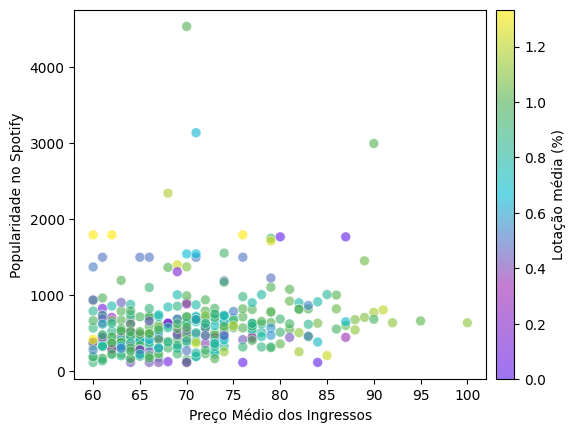

In [33]:
preco_medio = agrupar(df, ['nome'], col_sel='preco')

df_artist = (
    df.groupby('nome')
      .agg(
          popularidade=('popularidade', 'mean'),
          preco=('preco', 'mean'),
          lotacao=('lotacao_pct', 'mean')
      )
      .reset_index()
)

scatter = plt.scatter(
    x = df_artist['popularidade'],
    y = df_artist['preco'],
    s=50,
    c=df_artist['nome'].map(lotacao_media),
    cmap=cmap_neon,
    alpha=0.6,
    edgecolors='#FFFFFF',
    linewidth=0.5
)

plt.xlabel('Preço Médio dos Ingressos')
plt.ylabel('Popularidade no Spotify')

plt.colorbar(scatter, label='Lotação média (%)', pad=0.02)

A popularidade dos artistas aparenta exercer pouca influência sobre os valores cobrados pelos ingressos. Da mesma forma, o preço médio dos ingressos não demonstra impacto significativo na presença de público nos shows.

C:\Users\marin\AppData\Local\Temp\ipykernel_31008\621520547.py:7: FutureWarning:

The provided callable <function mean at 0x0000015D7F13CB80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.

C:\Users\marin\AppData\Local\Temp\ipykernel_31008\576283475.py:14: UserWarning:

FixedFormatter should only be used together with FixedLocator



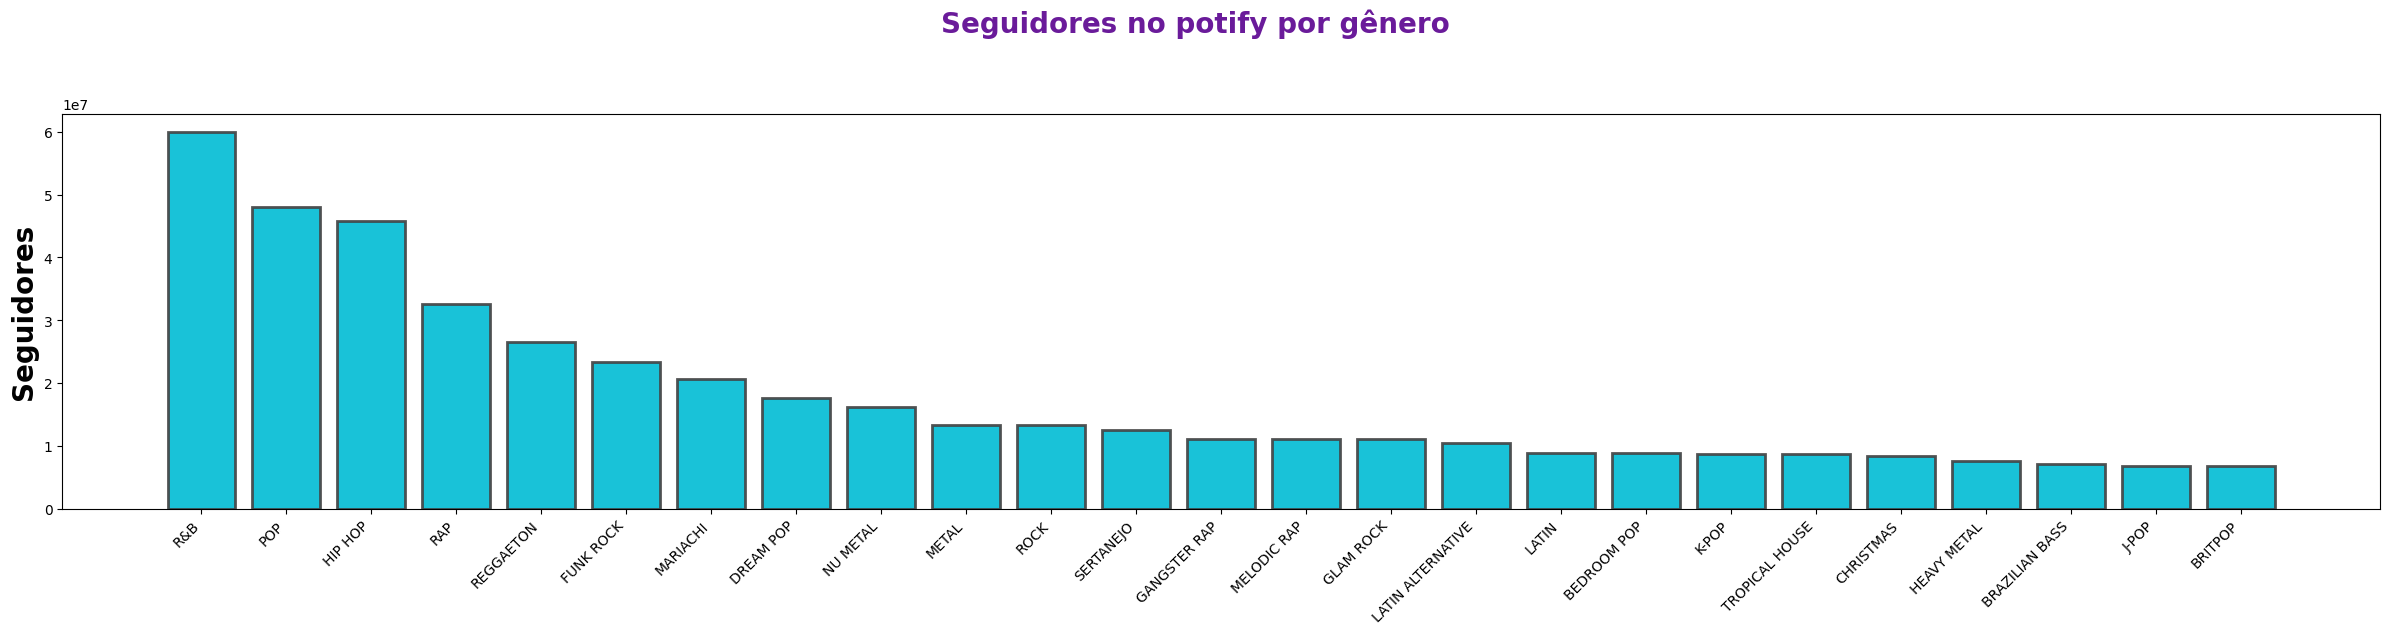

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(24, 6), sharey=True)

df1 = top_n(25, df, ['generos'], col_sel = 'seguidores')
ax.bar(
    df1['generos'],
    df1['seguidores'],
    color='#00BCD4',
    edgecolor='#424242',
    linewidth=2,
    alpha=0.9
)

ax.set_ylabel('Seguidores', fontsize=20, fontweight='bold')
ax.set_xticklabels(df1['generos'], rotation=45, ha='right')

fig.suptitle(
    'Seguidores no potify por gênero',
    fontsize=20,
    fontweight='bold',
    y=1.05, 
    color='#6A1B9A'
)

plt.tight_layout()
plt.show()

Ao comparar o número de seguidores dos artistas no Spotify por gênero musical, observa-se que os shows com maior taxa percentual de lotação não seguem uma lógica diretamente associada a esse indicador de popularidade.

Também nota-se uma grande variabilidade de gêneros dentro da base de dados; portanto, essa variável será usada de forma clusterizada para melhor entendiemtno e desempenho do modelo. 

In [35]:
df['generos'].nunique()

105

Deviodo a grande quantidade de diferentes possíveis valores de generos, utilizarei 15 clusters.

#### Comparativo em relação ao preço de ingressos 

C:\Users\marin\AppData\Local\Temp\ipykernel_31008\621520547.py:7: FutureWarning:

The provided callable <function mean at 0x0000015D7F13CB80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.



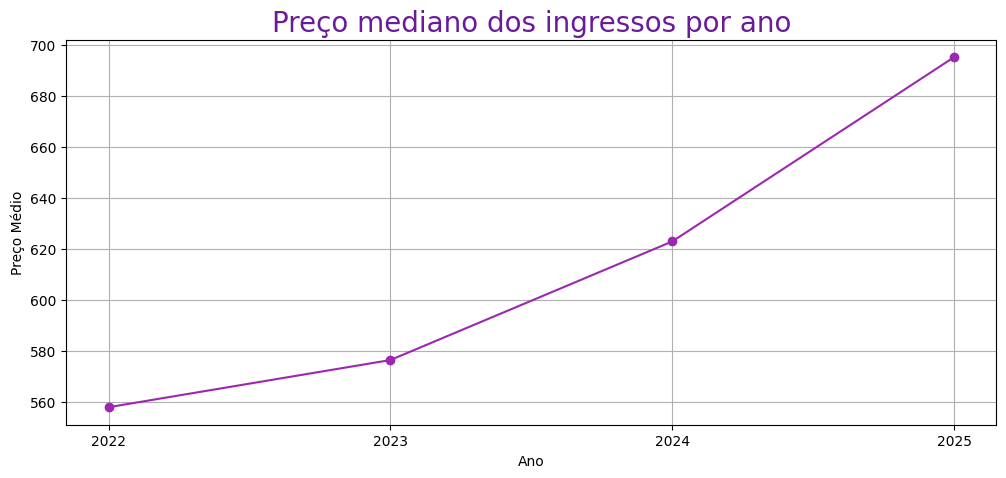

In [36]:
pm = agrupar(df, ['ano'], col_sel='preco_medio')

plt.figure(figsize=(12,5))
plt.plot(pm.index, pm.values, marker='o', color = '#9C27B0')
plt.title('Preço mediano dos ingressos por ano', color = '#6A1B9A',  fontsize = 20 )
plt.xlabel('Ano')
plt.ylabel('Preço Médio')
plt.grid(True)
plt.show()

Observa-se que o aumento dos valores dos ingressos apresenta forte relação com o avanço do tempo. Considerando a inflação acumulada no Brasil nos últimos anos

| Ano | Inflação Acumulada* |
|:--------:|---------:|
| 2022 | 5,79% |
| 2023 | 4,62% |
| 2024 | 4,83% |
| 2025 | 5,35% (ainda não consolidada) |

percebe-se que o crescimento médio dos preços dos ingressos supera de forma significativa o que seria esperado apenas pela correção inflacionária.

Esse resultado sugere que outros fatores, além da inflação, podem estar contribuindo para a elevação dos preços, como aumento de custos operacionais, maior demanda por eventos ao vivo no período pós-pandemia e mudanças na estratégia de precificação do setor.

*bcb.gov.br

#### Conclusão 

A análise exploratória permitiu compreender os principais padrões do mercado de shows em São Paulo entre 2021 e 2025. Observou-se um pico de eventos em 2022 e 2023, possivelmente relacionado ao represamento causado pela pandemia, além de forte influência sazonal, especialmente nos meses associados a grandes festivais. Variáveis climáticas não demonstraram impacto relevante na ocorrência de shows ou na presença de público.

De modo geral, a maior parte dos shows apresenta taxas de lotação elevadas, frequentemente acima de 95%, sem que haja crescimento proporcional à quantidade de eventos. Não foi identificada relação direta entre a capacidade dos locais, o preço médio dos ingressos ou a popularidade dos artistas em plataformas digitais com a presença de público. Da mesma forma, a existência de setores de maior ou menor luxo não parece interferir significativamente na lotação.

Observou-se ainda que o aumento dos preços dos ingressos ao longo do tempo supera a inflação acumulada no período, sugerindo a atuação de fatores adicionais na formação de preços. Em relação aos gêneros musicais e artistas, foram identificados comportamentos distintos entre quantidade de shows, público e arrecadação.

Adicionalmente, identificou-se que shows realizados durante festivais apresentam um comportamento de público significativamente distinto, com padrões atípicos de lotação e arrecadação, caracterizando outliers relevantes em relação aos demais eventos. Em função disso, optou-se por excluir shows ocorridos em festivais da base de modelagem, de modo a garantir maior homogeneidade e robustez estatística às análises subsequentes.

Por fim, considerando a elevada diversidade de gêneros musicais e a presença de categorias com baixa representatividade individual, será realizada a clusterização dos gêneros musicais, permitindo reduzir a dimensionalidade da base e capturar padrões comportamentais mais consistentes para a etapa de modelagem.

Esses resultados indicam que a lotação dos shows é influenciada por múltiplos fatores combinados, reforçando a necessidade de avançar para análises de correlação e modelagem, a fim de testar hipóteses e identificar as variáveis com maior poder explicativo.

In [37]:
df = df.groupby(['nome', 'data', 'nome_local']).agg({
    'ano': 'first',
    'Categoria_Local': 'first',
    'Tipo_Espaco': 'first',
    'generos': 'first',
    'popularidade': 'mean',
    'seguidores': 'mean',
    'lotacao': 'mean',
    'preco_medio': 'mean',
    'dia_semana': 'first',
    'tipo_dia': 'first',
    'mes': 'first',
    'distancia_dias_anterior': 'mean'
}).reset_index(drop=True)

In [38]:
gen_stats = (
    df.groupby('generos')['lotacao']
    .agg(['mean', 'median', 'std', 'count'])
    .reset_index()
)
gen_stats = gen_stats[gen_stats['count'] >= 5]
X = gen_stats[['mean', 'median', 'std']]
X_scaled = StandardScaler().fit_transform(X)
kmeans = KMeans(n_clusters=15, random_state=42)
gen_stats['cluster'] = kmeans.fit_predict(X_scaled)
map_cluster = dict(zip(gen_stats['generos'], gen_stats['cluster']))
df['genero_cluster'] = df['generos'].map(map_cluster).fillna('Outros')
gen_stats.groupby('cluster')[['mean','median','std','count']].mean()
df.head()

,ano,Categoria_Local,Tipo_Espaco,generos,popularidade,seguidores,lotacao,preco_medio,dia_semana,tipo_dia,mes,distancia_dias_anterior,genero_cluster
0,2023,MEDIAS CASAS,CASA DE SHOWS,ROCK,79.0,10256384.0,8000.0,635.000000,TERCA-FEIRA,DIA UTIL,JULHO,-11.500000,14.0
1,2022,MEDIAS CASAS,CASA DE SHOWS,METALCORE,69.0,2525628.0,3200.0,467.000000,QUINTA-FEIRA,DIA UTIL,MARÇO,-81.500000,0.0
2,2022,MEDIAS CASAS,CASA DE SHOWS,NEW WAVE,72.0,2940118.0,8000.0,466.666667,SEGUNDA-FEIRA,DIA UTIL,JULHO,-167.666667,Outros
3,2022,MEDIAS CASAS,CASA DE SHOWS,NEW WAVE,72.0,2940118.0,8000.0,466.666667,TERCA-FEIRA,DIA UTIL,JULHO,0.333333,Outros
4,2025,MEDIAS CASAS,CASA DE SHOWS,J-POP,76.0,6797031.0,8000.0,710.000000,QUARTA-FEIRA,DIA UTIL,AGOSTO,333.000000,Outros


In [39]:
df.to_csv('../data/temp/base_projeto_temp.csv', index=False, encoding='utf-8-sig')

## Base de Dados de Artistas

Como criei os clusters dentro da base de dados do projeto, farei o mesmo para a base de dados de artistas. Para isso utilizarei a base df para mapeamento da segunda.

In [79]:
df_art = pd.read_csv('../data/temp/artistas_projeto.csv', sep = ',')

In [80]:
df_art.head()

,nome,generos,popularidade,seguidores,imagem
0,ARIJIT SINGH,HINDI POP,90,165739069,https://i.scdn.co/image/ab6761610000e5eb5ba2d7...
1,TAYLOR SWIFT,POP,100,146601270,https://i.scdn.co/image/ab6761610000e5ebe2e8e7...
2,ED SHEERAN,SOFT POP,89,123163279,https://i.scdn.co/image/ab6761610000e5ebd55c95...
3,BILLIE EILISH,POP,92,119521349,https://i.scdn.co/image/ab6761610000e5eb4a21b4...
4,THE WEEKND,POP,95,113983998,https://i.scdn.co/image/ab6761610000e5eb9e5289...


In [81]:
df_map = (df.groupby('generos')['genero_cluster'].agg(lambda x: Counter(x).most_common(1)[0][0]).to_dict())

df_map = {str(k).upper().strip(): v for k, v in df_map.items()}
fallback_map = df_map.copy() 

Caso não exista o gênero no mapeamento, o valor de genero_cluster será substituído por clusterização em relação à popularidade. 

In [83]:
q1, q3 = df_art['popularidade'].quantile([0.25, 0.75])

def cluster_by_popularidade(pop):
    if pd.isna(pop):
        return 'Outros'

    if pop >= q3:
        return 'TOP'
    elif pop <= q1:
        return 'Nicho'
    else:
        return 'Intermediario'

In [84]:
def get_cluster(genero, popularidade):
    if pd.isna(genero):
        return cluster_by_popularidade(popularidade)

    key = genero.upper().strip()

    if key in df_map:
        return df_map[key]

    match = get_close_matches(key, df_map.keys(), n=1, cutoff=0.7)
    if match:
        return df_map[match[0]]

    return cluster_by_popularidade(popularidade)
    
df_art['genero_cluster'] = [get_cluster(g, p) for g, p in zip(df_art['generos'], df_art['popularidade'])]

In [85]:
cluster_pop = (
    df
    .groupby('genero_cluster')['popularidade']
    .mean()
    .sort_values()
)

low = cluster_pop.index[0]
mid = cluster_pop.index[len(cluster_pop)//2]
high = cluster_pop.index[-1]

sub_map = {
    'Nicho': low,
    'Intermediario': mid,
    'TOP': high
}

df_art['genero_cluster'] = df_art['genero_cluster'].replace(sub_map)

In [87]:
df_art.to_csv('../data/processed/base_artista_simulador.csv', index=False, encoding='utf-8-sig')